## Numerical Solution for Burguers Equation

Simple finite difference method solution

In [180]:
import numpy as np

h = 250
n = 2000
Teval = 0.8
Xeval = [-1,1]
dx = (Xeval[1]-Xeval[0])/h
dt = Teval/n
v = 0.01/np.pi

In [181]:
time = np.linspace(0, Teval, n)
x = np.linspace(Xeval[0], Xeval[1], h)
u_sim = np.zeros((np.size(time), np.size(x)))
u_sim[0] = - np.sin(np.pi * x)

In [182]:
def f(u):
    return (u**2)/2
for t in range(len(time)-1):
    fx = (f(u_sim[t][2:]) - f(u_sim[t][:-2]))/(2*dx)
    uxx = v * (( u_sim[t][2:] - 2 * u_sim[t][1:-1] + u_sim[t][:-2] ) / (dx**2))
    u_sim[t+1][1:-1] = u_sim[t][1:-1] + dt*(v*uxx - fx)
    u_sim[t+1][0] = 0
    u_sim[t+1][-1] = 0

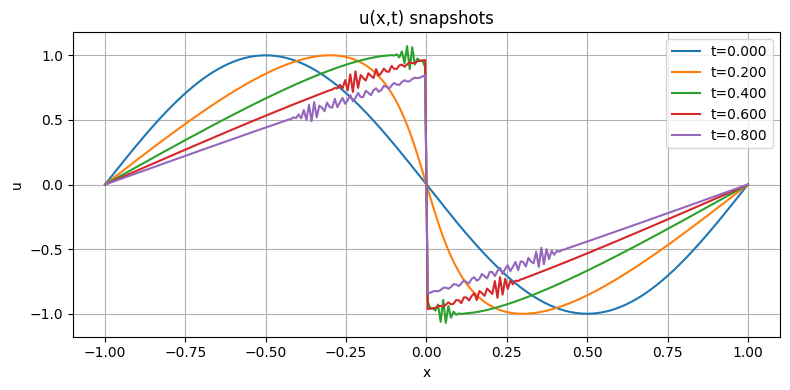

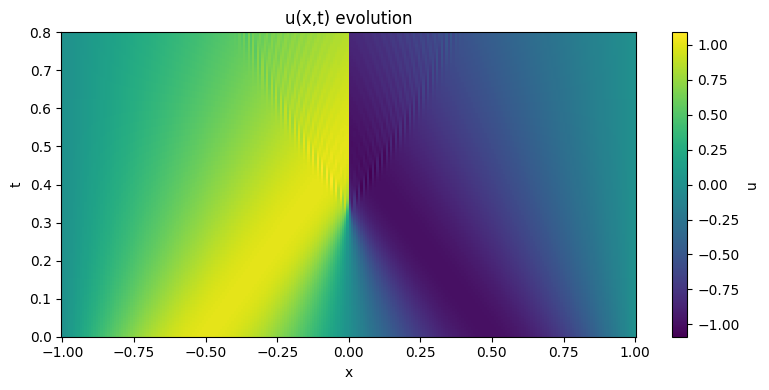

In [183]:
# Plot snapshots and space-time colormap
import matplotlib.pyplot as plt
%matplotlib inline

# few snapshots in time
plt.figure(figsize=(8,4))
for idx in np.linspace(0, len(time)-1, 5, dtype=int):
    plt.plot(x, u_sim[idx], label=f't={time[idx]:.3f}')
plt.xlabel('x')
plt.ylabel('u')
plt.title('u(x,t) snapshots')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# space-time colormap
plt.figure(figsize=(8,4))
plt.pcolormesh(x, time, u_sim, shading='auto')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('t')
plt.title('u(x,t) evolution')
plt.tight_layout()
plt.show()

## Development of Physics Informed NN with Boundary and Initial Conditions

In [130]:
import torch
import torch.nn as nn
import torch.optim as opt

In [ ]:
x_values = torch.linspace(-1,1,25).view(-1,1) #Spatial Points
t_values = torch.linspace(0,1,25).view(-1,1) #Temporal Points
x_collocation, t_collocation = torch.meshgrid(x_values.squeeze(), t_values.squeeze(), indexing = "xy") #Mashgrid
x_collocation = x_collocation.reshape(-1, 1) #Select Internal Points
t_collocation = t_collocation.reshape(-1, 1)

#Extract Boundary Conditions
x_bondary_left = torch.full_like(t_values, -1) 
x_bondary_right = torch.full_like(t_values, 1)
t_bondary = t_values

#Extract Initial Condition
t_initial_condition = torch.zeros_like(x_values)
x_initial_condition = x_values

### Neural Network Definition

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.hidden = nn.Sequential(
            nn.Linear(2, 20), # 2D inputs (x, t)
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,20),
            nn.Tanh(),
            nn.Linear(20,1) # 1D output (u)
            
         )


    def forward(self, x, t):
        inputs = torch.cat([x, t], dim = 1) # Concatenate with t
        u = self.hidden(inputs)

        return u

In [ ]:
def pde_residual(x, t, model, nu = 0.01): #Defines burgers residuals 
    x.requires_grad = True
    t.requires_grad = True

    u = model(x, t)
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph = True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph = True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), create_graph = True)[0]

    residual = u_t + u * u_x - nu/(np.pi) * u_xx

    return residual

def initial_condition(x): #Loss due to initial condition
    return -torch.sin(np.pi * x)

def bondary_condition(x, t): #Loss due to bondary conditions
    return torch.zeros_like(t)

In [307]:
x = torch.linspace(-1, 1, 100).view(-1,1)
t = torch.linspace(0, 1, 100).view(-1,1)
x_train, t_train = torch.meshgrid(x.squeeze(), t.squeeze(), indexing = "xy") #Mashgrid
x_train = x_train.reshape(-1, 1)
t_train = t_train.reshape(-1, 1)

In [308]:
model = PINN()
optmizer = opt.Adam(model.parameters(), lr = 0.001)

### Treinamento para a PINN

In [309]:
num_epochs = 12000
for epoch in range(num_epochs):
    model.train()

    u_pred = model(x, torch.zeros_like(x))
    u_true = initial_condition(x)

    loss_ic = torch.mean((u_pred - u_true)**2)

    u_pred_left = model(torch.full_like(t, -1), t)
    u_pred_right = model(torch.full_like(t, 1), t)
    loss_bc = torch.mean((u_pred_left - bondary_condition(torch.full_like(t, -1), t))**2) + \
         torch.mean((u_pred_right - bondary_condition(torch.full_like(t, 1), t))**2) 

    residual = pde_residual(x_train, t_train, model)
    loss_pde = torch.mean(residual**2)

    loss = 3*loss_ic + loss_bc + loss_pde

    optmizer.zero_grad()
    loss.backward()
    optmizer.step()
    
    if (epoch) % 500 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}' )

    

Epoch [1/12000], Loss: 1.3874
Epoch [501/12000], Loss: 0.1844
Epoch [1001/12000], Loss: 0.1424
Epoch [1501/12000], Loss: 0.0676
Epoch [2001/12000], Loss: 0.0303
Epoch [2501/12000], Loss: 0.0294
Epoch [3001/12000], Loss: 0.0223
Epoch [3501/12000], Loss: 0.0147
Epoch [4001/12000], Loss: 0.0162
Epoch [4501/12000], Loss: 0.0184
Epoch [5001/12000], Loss: 0.0136
Epoch [5501/12000], Loss: 0.0081
Epoch [6001/12000], Loss: 0.0102
Epoch [6501/12000], Loss: 0.0058
Epoch [7001/12000], Loss: 0.0051
Epoch [7501/12000], Loss: 0.0044
Epoch [8001/12000], Loss: 0.0044
Epoch [8501/12000], Loss: 0.0041
Epoch [9001/12000], Loss: 0.0034
Epoch [9501/12000], Loss: 0.0031
Epoch [10001/12000], Loss: 0.0044
Epoch [10501/12000], Loss: 0.0029
Epoch [11001/12000], Loss: 0.0026
Epoch [11501/12000], Loss: 0.0023


## PINN's Solution

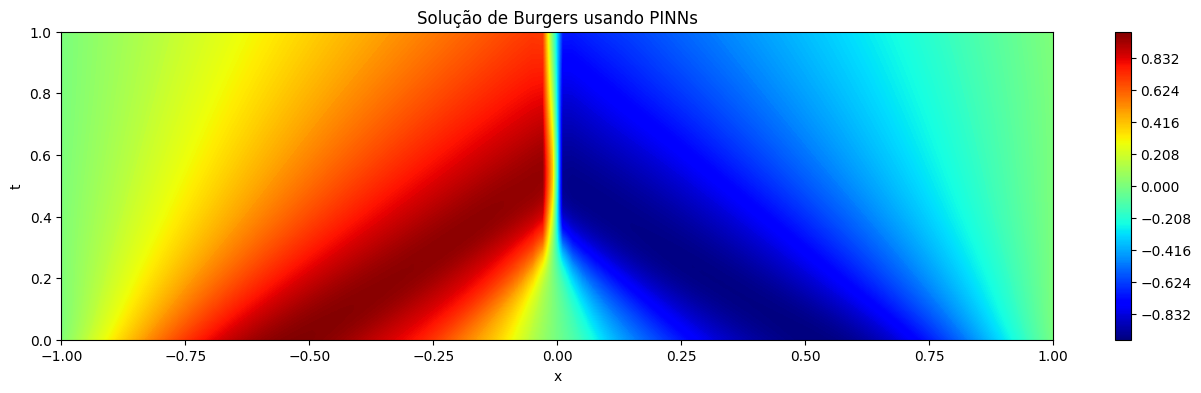

In [ ]:
x_test = torch.linspace(-1, 1, 100).view(-1, 1)
t_test = torch.linspace(0, 1, 100).view(-1, 1)
x_test, t_test = torch.meshgrid(x_test.squeeze(), t_test.squeeze(), indexing = "xy") #Mashgrid
x_test = x_test.reshape(-1, 1)
t_test = t_test.reshape(-1, 1)

model.eval()

with torch.no_grad():
    u_pred = model(x_test, t_test).numpy()

x_test= x_test.numpy().reshape(100, 100)
t_test= t_test.numpy().reshape(100, 100)
u_pred =u_pred.reshape(100, 100)

plt.figure(figsize=(16, 4))
plt.contourf(x_test, t_test, u_pred, levels=250, cmap='jet')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINNs Burgers Solutionn')
plt.show()